## **NETFLIX**

In [44]:
#importation des bibliotheque 
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [29]:
# importationo du jeux de donnée 
df_netflix = pd.read_csv(r'C:\Users\keita\OneDrive\Desktop\Data_source\Netflix_user_analitics\netflix_user_behavior_dataset.csv')

## **Analyse descriptive du jeux de donnée**

In [30]:
print('_ '*30)
print('Affichage des 5 premières lignes du dataset')
print('_ '*30)
display(df_netflix.head(5))
print('_ '*30)
print('Types des colonnes')
print('_ '*30)
display(df_netflix.dtypes)    
print('_ '*30)
print('Informations sur le dataset')   
print('_ '*30)
display(df_netflix.info())
print('_ '*30)
print('Statistiques descriptives du dataset')
print('_ '*30)
display(df_netflix.describe()) 
print('_ '*30)
print('Nombre de colonnes et de lignes du dataset')
print('_ '*30)
print(f'Nombre de lignes : {df_netflix.shape[0]}')
print(f'Nombre de colonnes : {df_netflix.shape[1]}')

_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Affichage des 5 premières lignes du dataset
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Types des colonnes
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


user_id                          str
age                            int64
gender                           str
country                          str
account_age_months             int64
subscription_type                str
monthly_fee                  float64
payment_method                   str
primary_device                   str
devices_used                   int64
favorite_genre                   str
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                          str
dtype: object

_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Informations sur le dataset
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  str    
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  str    
 3   country                    50000 non-null  str    
 4   account_age_months         50000 non-null  int64  
 5   subscription_type          50000 non-null  str    
 6   monthly_fee                50000 non-null  float64
 7   payment_method             50000 non-null  str    
 8   primary_device             50000 non-null  str    
 9   devices_used               50000 non-null  int64  
 10  favorite_genre             50000 non-null  str    
 11  avg_watch_time_minu

None

_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Statistiques descriptives du dataset
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Nombre de colonnes et de lignes du dataset
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Nombre de lignes : 50000
Nombre de colonnes : 20


In [65]:
categorical_cols = ['gender', 'country', 'subscription_type', 'payment_method', 'primary_device', 'favorite_genre', 'churned']
numerical_variable = df_netflix[['age','account_age_months','monthly_fee','devices_used','avg_watch_time_minutes','watch_sessions_per_week','binge_watch_sessions','completion_rate','rating_given','content_interactions','recommendation_click_rate','days_since_last_login']]

for columns in categorical_cols:
    if columns in df_netflix.columns:
        df_netflix[columns] = df_netflix[columns].astype('category')
    
for columns in numerical_variable.columns:
    if columns in df_netflix.columns:
        df_netflix[columns] = pd.to_numeric(df_netflix[columns], errors='coerce')
    
# v/rification des colonnes manquantes 
print('_ '*30)
print('Nombre de valeurs manquantes par colonne')
print('_ '*30)
display(df_netflix.isnull().sum())
print('_ '*30)
print('variables id uniques')
print('_ '*30)
display(df_netflix['user_id'].duplicated().sum())
print('__ '*30)
print('les types de variables')
print('__ '*30)
display(df_netflix.dtypes)

_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
Nombre de valeurs manquantes par colonne
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


user_id                       0
age                           0
account_age_months            0
monthly_fee                   0
devices_used                  0
avg_watch_time_minutes        0
watch_sessions_per_week       0
binge_watch_sessions          0
completion_rate               0
rating_given                  0
content_interactions          0
recommendation_click_rate     0
days_since_last_login         0
gender_Male                   0
gender_Other                  0
country_Brazil                0
country_Canada                0
country_France                0
country_Germany               0
country_India                 0
country_Japan                 0
country_Spain                 0
country_UK                    0
country_USA                   0
subscription_type_Premium     0
subscription_type_Standard    0
payment_method_Debit Card     0
payment_method_PayPal         0
payment_method_UPI            0
primary_device_Mobile         0
primary_device_Smart TV       0
primary_

_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 
variables id uniques
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 


np.int64(0)

__ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ 
les types de variables
__ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ __ 


user_id                            str
age                              int64
account_age_months               int64
monthly_fee                    float64
devices_used                     int64
avg_watch_time_minutes           int64
watch_sessions_per_week          int64
binge_watch_sessions             int64
completion_rate                  int64
rating_given                   float64
content_interactions             int64
recommendation_click_rate        int64
days_since_last_login            int64
gender_Male                       bool
gender_Other                      bool
country_Brazil                    bool
country_Canada                    bool
country_France                    bool
country_Germany                   bool
country_India                     bool
country_Japan                     bool
country_Spain                     bool
country_UK                        bool
country_USA                       bool
subscription_type_Premium         bool
subscription_type_Standar

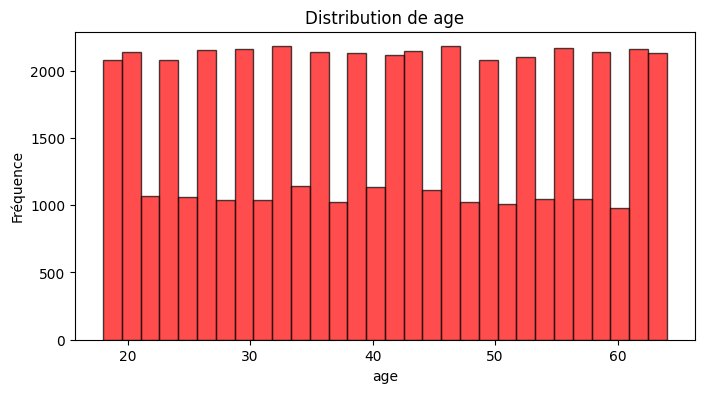

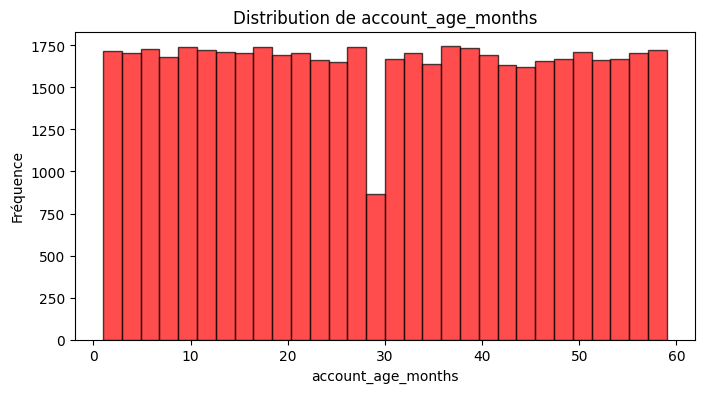

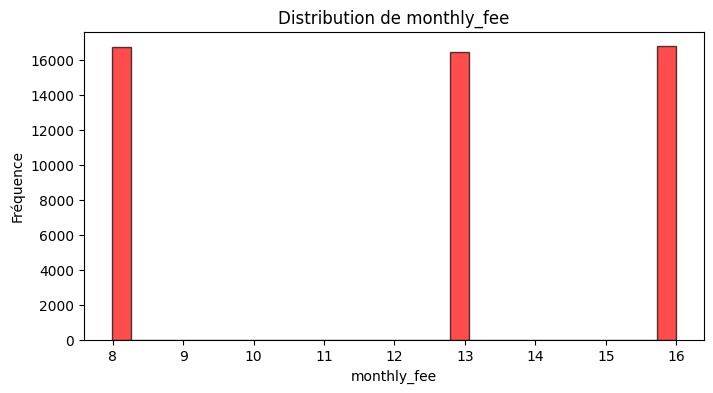

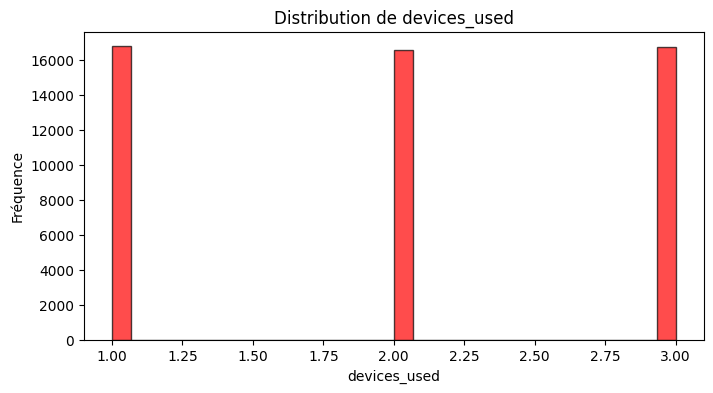

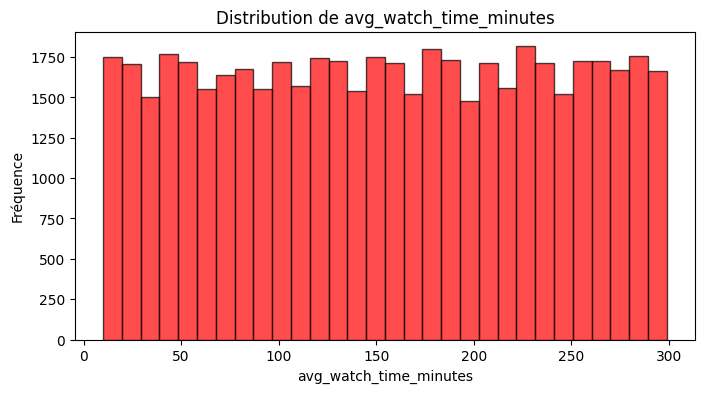

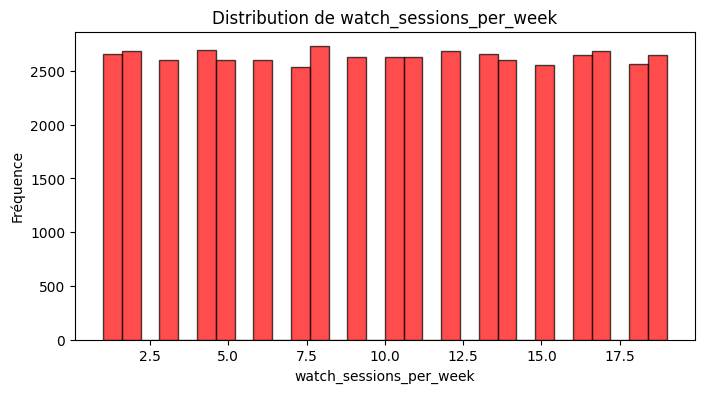

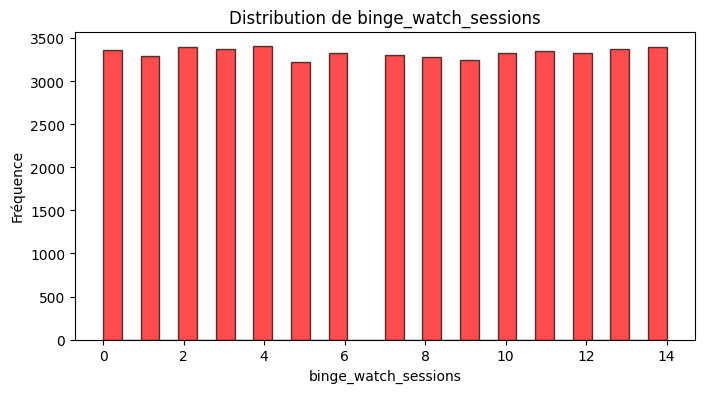

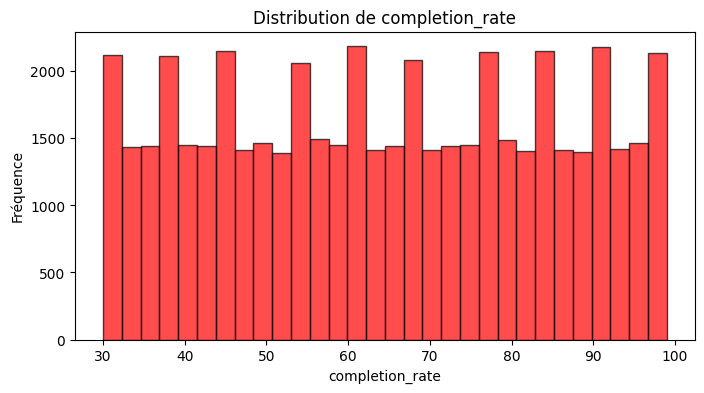

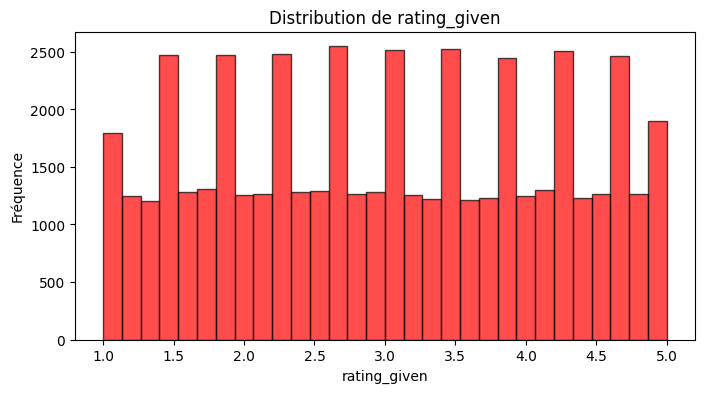

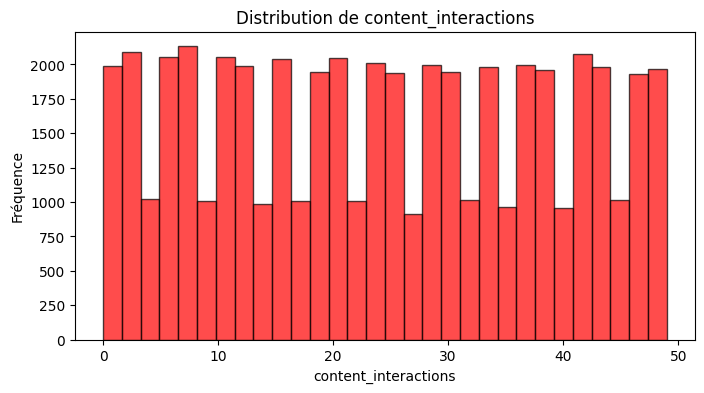

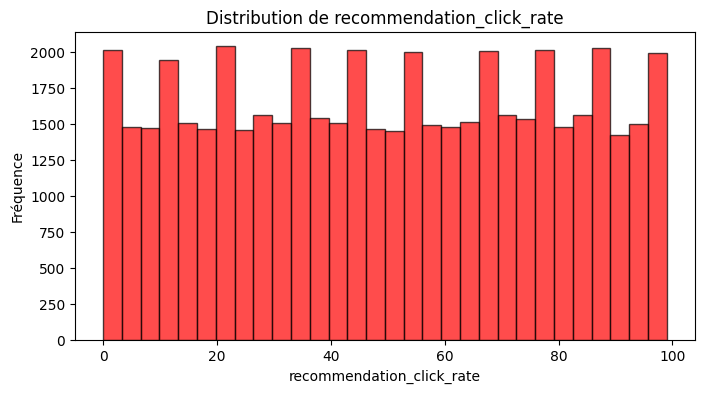

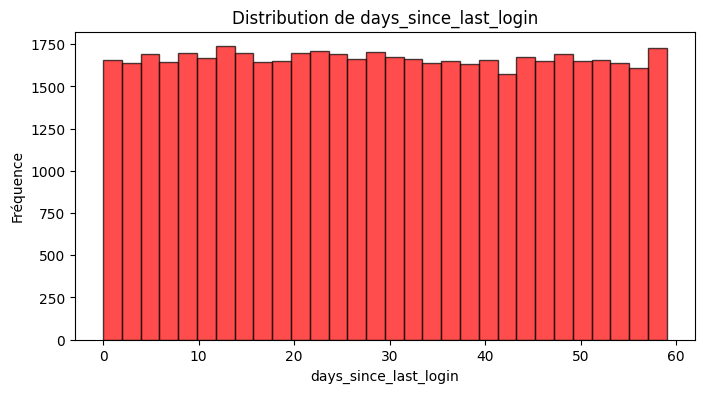

In [66]:
# affichage des distributions des variables num/rique 
numerical_variable = df_netflix[['age','account_age_months','monthly_fee','devices_used','avg_watch_time_minutes','watch_sessions_per_week','binge_watch_sessions','completion_rate','rating_given','content_interactions','recommendation_click_rate','days_since_last_login']]

for column in numerical_variable.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df_netflix[column], bins=30, color='r', alpha=0.7, edgecolor='black')
    plt.title(f'Distribution de {column}')
    plt.xlabel(column)
    plt.ylabel('Fréquence')
    plt.show()

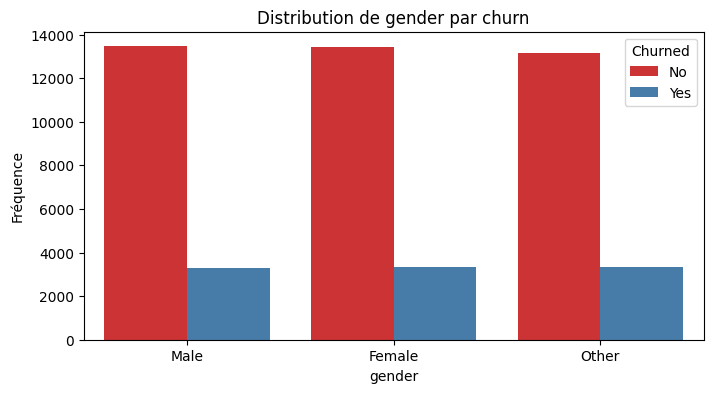

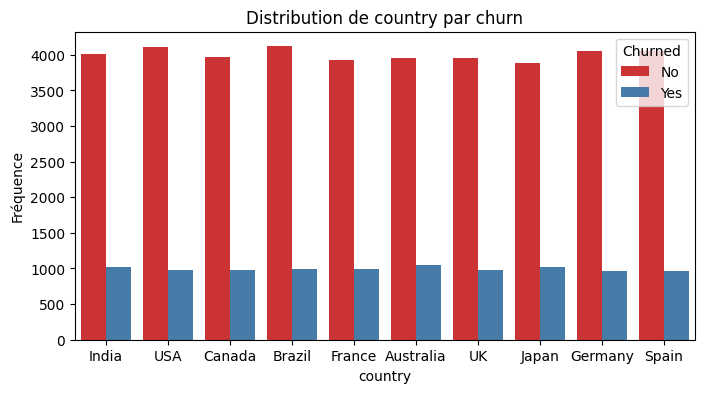

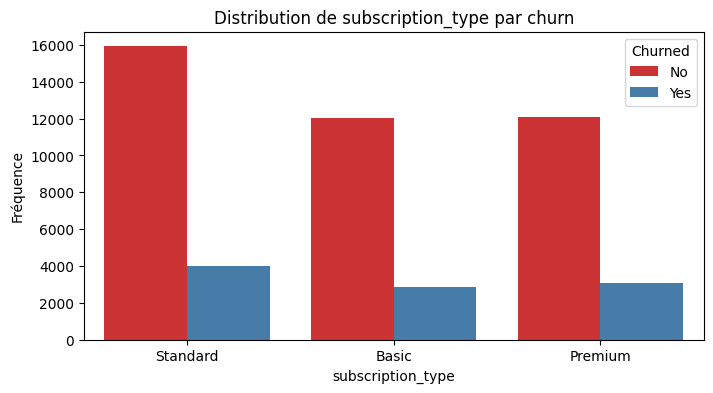

C:\Users\keita\AppData\Local\Temp\ipykernel_29152\3883925967.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churned', loc='upper right')


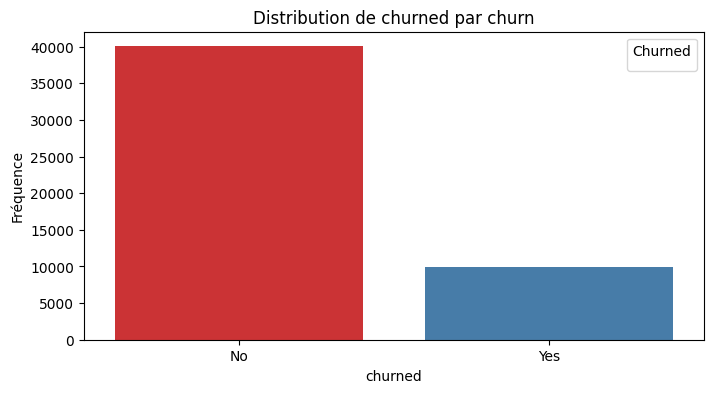

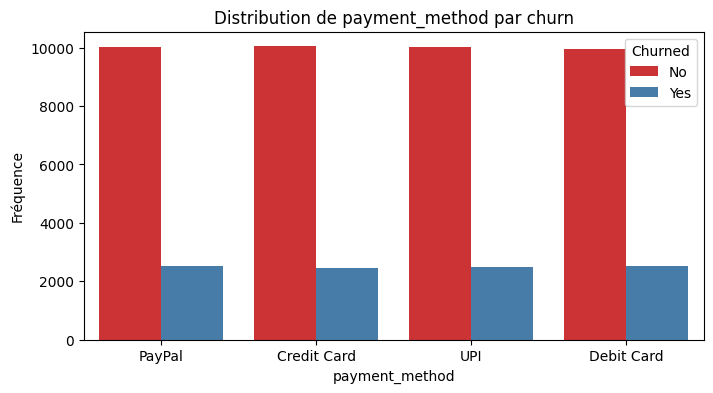

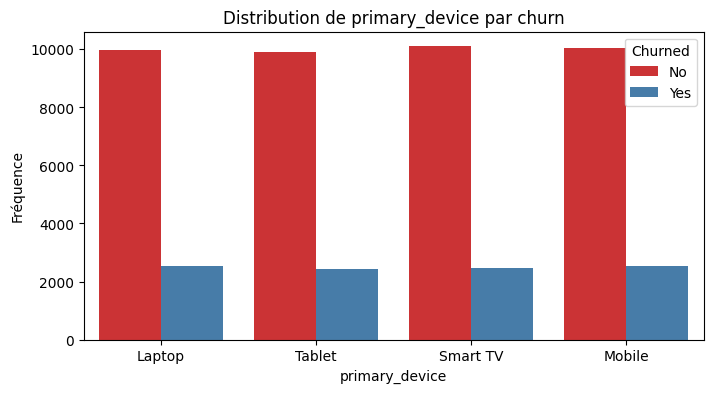

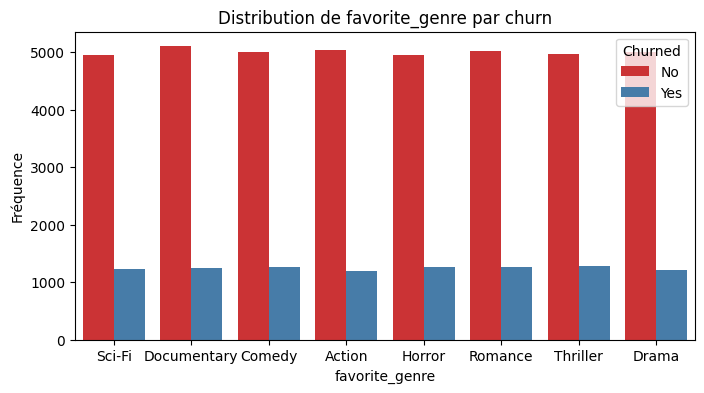

In [39]:
# affichage des distributions des variables categoriques 
categorical_variable = df_netflix[['gender', 'country', 'subscription_type', 'churned', 'payment_method', 'primary_device', 'favorite_genre']]

for column in categorical_variable.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=column, hue='churned', data=df_netflix, palette='Set1')
    plt.title(f'Distribution de {column} par churn')
    plt.xlabel(column)
    plt.ylabel('Fréquence')
    plt.legend(title='Churned', loc='upper right')
    plt.show()

In [120]:
x = df_netflix.drop(columns=['user_id', 'churned', 'churned_Yes'])
y = df_netflix['churned']
# Correct order from train_test_split: X_train, X_test, y_train, y_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

reg_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, solver='saga', class_weight='balanced'))
reg_log.fit(x_train, y_train)
y_pred = reg_log.predict(x_test)

In [123]:
# accuracy, precision, recall, f1-score
report = classification_report(y_test, y_pred)
print('Classification Report:')
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.51      0.62      8046
           1       0.19      0.47      0.27      1954

    accuracy                           0.50     10000
   macro avg       0.49      0.49      0.45     10000
weighted avg       0.68      0.50      0.55     10000



In [114]:
# REPORT SVM
report = classification_report(y_test, y_pred_svm)
print('Classification Report for SVM:') 
print(report)

Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.80      0.58      0.67      8046
           1       0.19      0.40      0.26      1954

    accuracy                           0.55     10000
   macro avg       0.49      0.49      0.47     10000
weighted avg       0.68      0.55      0.59     10000

